In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

b = np.load('rmd17_ethanol.npz')
print(b['nuclear_charges'])


[6 6 8 1 1 1 1 1 1]
[6 6 6 6 6 6 6 8 8 8 6 6 8 1 1 1 1 1 1 1 1]


In [2]:
all_coords = b['coords']
all_energies = b['energies']

print(all_coords.shape)
print(all_energies.shape)

N = len(all_coords)
 
perm = np.random.permutation(N)

coords = all_coords[perm[:2000]]        # random 1000 selected out of the 100000
energies = all_energies[perm[:2000]]

print(coords.shape)
print(energies.shape)


(100000, 9, 3)
(100000,)
(2000, 9, 3)
(2000,)


In [3]:
bonds = [(0,1), (0,3), (0,4), (0,5), (1,2), (1,6), (1,7), (2,8)]

def bond_lengths(coords):
    lengths = []
    for i in range(len(coords)):
        for a,b in bonds:
            length = np.linalg.norm(coords[i,a,:]-coords[i,b,:])

            lengths.append(length)
    return(lengths)

ben_lengths = np.array(bond_lengths(coords))
BL = ben_lengths.reshape(len(coords), len(bonds))
print(BL)
print(BL.shape)

[[1.5837143  1.13337469 1.1817702  ... 1.08703105 1.1540079  0.95964406]
 [1.48581687 1.11881342 1.11952285 ... 1.02735524 1.08478853 0.97409705]
 [1.57508894 1.05088107 1.10336303 ... 1.12412395 1.06916451 1.01038926]
 ...
 [1.50922209 1.0722571  1.18728116 ... 0.97960587 1.15896484 0.97933143]
 [1.54697085 1.13675788 1.10421626 ... 1.07792959 1.08381954 1.00599923]
 [1.46670571 1.16943492 1.20893087 ... 1.0942723  1.10904327 0.95392343]]
(2000, 8)


In [4]:
angles = [(1, 0, 3), (1, 0, 4), (1, 0, 5), (3, 0, 4), (3, 0, 5), (4, 0, 5), (0, 1, 2), (0, 1, 6), (0, 1, 7),   
(2, 1, 6), (2, 1, 7), (6, 1, 7), (1, 2, 8)]

def bond_angles(coords):
    ben_angles = []
    for o in range(len(coords)):
        for i,j,k in angles:
            length1 = np.linalg.norm(coords[o,i,:]-coords[o,j,:])
            length2 = np.linalg.norm(coords[o,k,:]-coords[o,j,:])


            dot_prod = np.dot((coords[o,i,:]-coords[o,j,:]),(coords[o,k,:]-coords[o,j,:]))


            cosang = dot_prod / (length1 * length2)


            ben_angles.append(np.acos(cosang))
    return(ben_angles)


benz_angles = np.array(bond_angles(coords))
AN = benz_angles.reshape(len(coords), len(angles))
print(AN)
print(AN.shape)

[[1.83486651 1.82838351 0.46720553 ... 1.52268686 1.78571119 1.977152  ]
 [1.98991627 1.85487198 0.50316393 ... 1.5446628  1.8004609  1.50743656]
 [1.8574112  1.93981912 0.45686828 ... 1.52891192 2.04248801 2.48533805]
 ...
 [1.87645182 1.76709768 0.59514235 ... 1.49052294 2.03831093 2.71106517]
 [1.97340081 1.88889644 0.46175505 ... 2.48742426 1.91177841 1.60170603]
 [1.94000902 2.02454729 0.44489573 ... 1.42740668 1.82481019 1.5770135 ]]
(2000, 13)


In [5]:
X = np.concatenate((BL,AN), axis=1)
y = np.array(energies)


print(X)
print(y)
print(X.shape)
print(y.shape)

[[1.5837143  1.13337469 1.1817702  ... 1.52268686 1.78571119 1.977152  ]
 [1.48581687 1.11881342 1.11952285 ... 1.5446628  1.8004609  1.50743656]
 [1.57508894 1.05088107 1.10336303 ... 1.52891192 2.04248801 2.48533805]
 ...
 [1.50922209 1.0722571  1.18728116 ... 1.49052294 2.03831093 2.71106517]
 [1.54697085 1.13675788 1.10421626 ... 2.48742426 1.91177841 1.60170603]
 [1.46670571 1.16943492 1.20893087 ... 1.42740668 1.82481019 1.5770135 ]]
[-97077.18090499 -97080.71336949 -97077.79470702 ... -97064.61303677
 -97081.62000081 -97076.4610381 ]
(2000, 21)
(2000,)


In [6]:
mu_X = X.mean(axis=0)
std_X = X.std(axis=0)

X_new = (X - mu_X)/ std_X

mu_y = y.mean()
std_y = y.std()

y_new = (y - mu_y)/ std_y

print(y_new)

[-0.21818767 -1.03559552 -0.36022069 ...  2.69000127 -1.24538887
 -0.05161137]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

print(y_train_t.shape)

torch.Size([1600, 1])


In [8]:
class Model(nn.Module):
    
    def __init__(self, input_features = 21, hidden1 = 64, hidden2 = 32, hidden3 = 16, output_features = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden1) 
        self.fc2 = nn.Linear(hidden1, hidden2) 
        self.fc3 = nn.Linear(hidden2, hidden3) 
        self.fc4 = nn.Linear(hidden3, output_features)
        self.ac1 = nn.SiLU()
        self.ac2 = nn.SiLU()
        self.ac3 = nn.SiLU()

    def forward(self, x):
        x = self.fc1(x) 
        x = self.ac1(x)
        x = self.fc2(x)
        x = self.ac2(x) 
        x = self.fc3(x)
        x = self.ac3(x)
        x = self.fc4(x) 
        return x

In [9]:
epochs = 1000
losses = []

torch.manual_seed(42)
model = Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay = 1e-3)

for epoch in range(epochs):

    model.train()

    y_pred = model(X_train_t) 
    loss = criterion(y_pred, y_train_t)    
    losses.append(loss.item()) 


    if epoch%10==0:
        print(f'Epoch: {epoch} and loss: {loss}') 

    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step() 

Epoch: 0 and loss: 1.017176628112793
Epoch: 10 and loss: 1.0087921619415283
Epoch: 20 and loss: 1.0001556873321533
Epoch: 30 and loss: 0.9908016920089722
Epoch: 40 and loss: 0.9801883101463318
Epoch: 50 and loss: 0.9677541255950928
Epoch: 60 and loss: 0.9529800415039062
Epoch: 70 and loss: 0.9354771971702576
Epoch: 80 and loss: 0.9150881767272949
Epoch: 90 and loss: 0.8919335007667542
Epoch: 100 and loss: 0.8663665652275085
Epoch: 110 and loss: 0.8387633562088013
Epoch: 120 and loss: 0.8092191815376282
Epoch: 130 and loss: 0.7775157690048218
Epoch: 140 and loss: 0.7434678673744202
Epoch: 150 and loss: 0.7072242498397827
Epoch: 160 and loss: 0.669361412525177
Epoch: 170 and loss: 0.6308193802833557
Epoch: 180 and loss: 0.5927248597145081
Epoch: 190 and loss: 0.5561470985412598
Epoch: 200 and loss: 0.5218059420585632
Epoch: 210 and loss: 0.48996832966804504
Epoch: 220 and loss: 0.46073073148727417
Epoch: 230 and loss: 0.4342094659805298
Epoch: 240 and loss: 0.4104122221469879
Epoch: 250 

C:\Users\home\AppData\Local\Temp\ipykernel_19332\2802147921.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


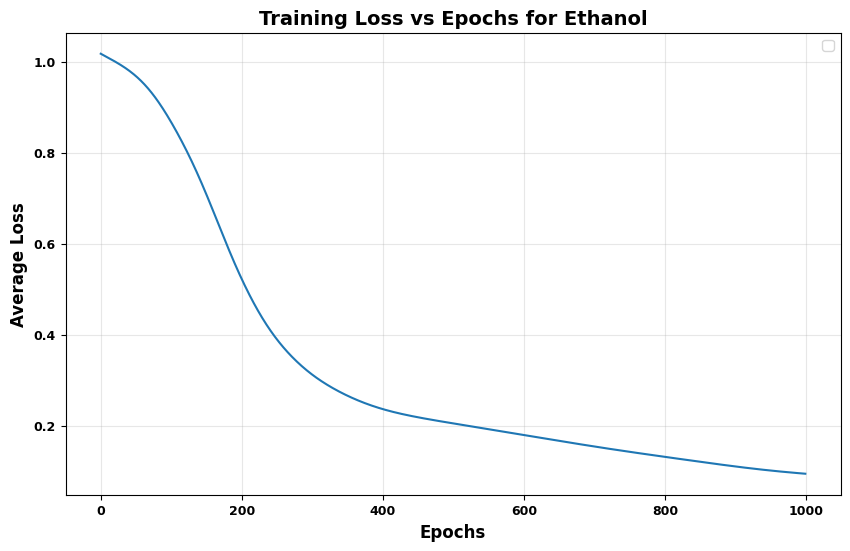

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), losses)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Average Loss', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('NNTrain_loss_vs_epoch_ethanol.png')
plt.title('Training Loss vs Epochs for Ethanol', fontsize=14, fontweight='bold')
plt.show()

In [11]:
model.eval()
with torch.no_grad():
    final_test_pred = model(X_test_t)
    final_test_loss = nn.MSELoss()
    loss = final_test_loss(final_test_pred, y_test_t)
print("final test loss:", float(loss))

pred_unnormalized = final_test_pred.numpy().squeeze() * std_y + mu_y
true_unnormalized = y_test_t.numpy().squeeze() * std_y + mu_y

final test loss: 0.2767355442047119


In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(true_unnormalized, pred_unnormalized)
mae = mean_absolute_error(true_unnormalized, pred_unnormalized)
mse = mean_squared_error(true_unnormalized, pred_unnormalized)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")  
print(f"MAE: {mae:.4f}")      
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7312
MAE: 1.6697
RMSE: 2.2734


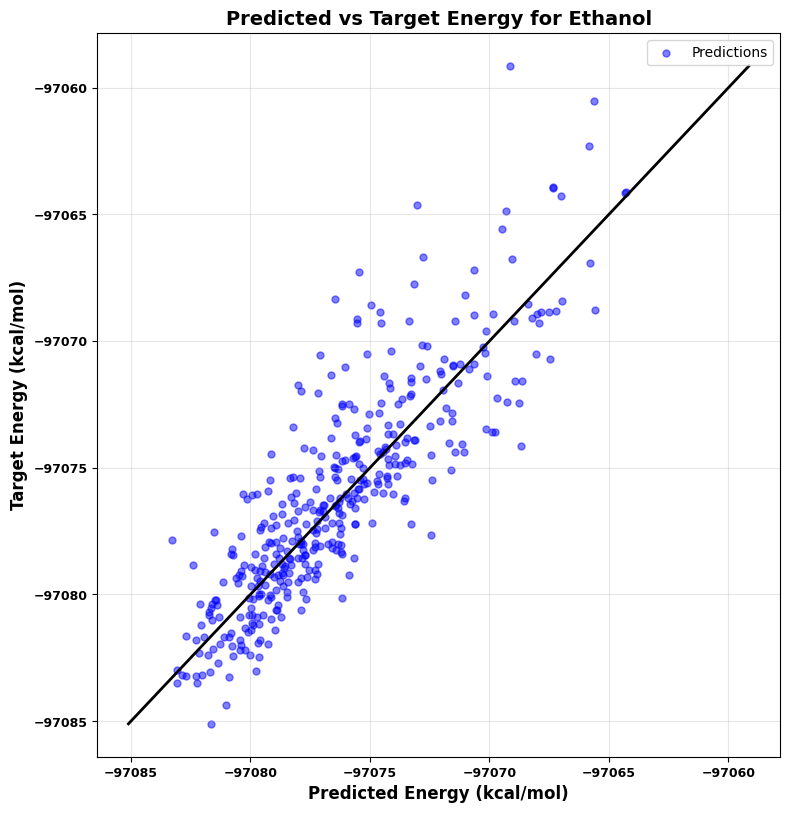

In [13]:
plt.figure(figsize=(8,8))
plt.scatter(pred_unnormalized, true_unnormalized, alpha=0.5, s=25, color='blue', label='Predictions')
plt.plot([true_unnormalized.min(), true_unnormalized.max()], 
         [true_unnormalized.min(), true_unnormalized.max()], 
         'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Predicted Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.ylabel('Target Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('NNNtarget_vs_predE_ethanol.png')
plt.title('Predicted vs Target Energy for Ethanol', fontsize=14, fontweight='bold')
plt.show()
